# 02 — Data Preparation

**Thesis:** *Nowcasting and Indicator Selection in a Data-Rich Environment: An Application to German GDP Growth*

---

This notebook prepares the raw predictor panel for modelling. It operates on the outputs of `01_data_understanding.ipynb`
and produces a **deduplicated, stationary, transformed predictor panel** (predictors are already seasonally adjusted or non-seasonal at source) ready for Elastic Net selection and DFM estimation.

**Prerequisites:** `data/panel/data_df.csv`, `data/metadata/data_dict_catalog.csv`, `data/qa/deduplication_decisions.csv`  
**Outputs:** `data/panel/data_transformed.csv`, `data/metadata/data_dict_enriched.csv`, `data/qa/stationarity_report.csv`

**Contents:**

| Step | Task |
|------|------|
| 0   | Setup — paths, imports, load data |
| 0.5 | **Deduplication & status filter** — apply `deduplication_decisions.csv`, tag `active` / `lagging` / `discontinued`, drop discontinued |
| 1   | Transformation status verification — confirm `data_df` is raw |
| 2   | Seasonality — metadata only (no in-house adjustment) |
| 3   | Apply transformations — log-difference and second log-difference per trafo code |
| 4   | Stationarity testing — ADF + KPSS joint test on the retained series |
| 5   | Stationarity summary — flag problem series, export reports |

> **Publication lags.** Lags in months come from optional review workbooks configured through `german_gdp_nowcasting.config.paths`. They are stored in `data/metadata/pub_lag_map.csv` and merged into `data_dict_enriched.csv` as `pub_lag`. Step 0.6 integrates lags and reinstates approved *new series* where applicable.

---
## Step 0 — Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 130)
plt.style.use('seaborn-v0_8-whitegrid')

# --- Portable repository setup ---
_repo = next(
    (base for base in (Path.cwd(), *Path.cwd().parents)
     if (base / "src" / "german_gdp_nowcasting").is_dir()),
    None,
)
if _repo is None:
    raise RuntimeError("Could not locate src/german_gdp_nowcasting.")
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from german_gdp_nowcasting.config import paths as _tp

FIG_DIR = _tp.NOTEBOOK_FIGURES / '02_data_preparation'
FIG_DIR.mkdir(parents=True, exist_ok=True)
if not _tp.PANEL_RAW_CSV.exists():
    raise FileNotFoundError(
        f'Missing {_tp.PANEL_RAW_CSV}. Run notebook 01 first, '
        'or set GERMAN_GDP_NOWCASTING_DATA_DIR to the prepared panel.'
    )

# --- Load data ---
data_df = pd.read_csv(_tp.PANEL_RAW_CSV, index_col='date', parse_dates=True)
data_dict = pd.read_csv(_tp.DATA_DICT_CATALOG_CSV, index_col='id')
# Full catalogue before Step 0.5 filters (used in Step 0.6 for reinstated series metadata)
data_dict_full = data_dict.copy()

# Cast nullable integer columns
for col in ['trafo', 'degree', 'block', 'factor_data']:
    data_dict[col] = data_dict[col].astype('Int64')

SAMPLE_END_STR = '2025-12'
data_df = data_df.loc[:SAMPLE_END_STR]

print(f'data_df    : {data_df.shape[0]} months × {data_df.shape[1]} indicators')
print(f'data_dict  : {data_dict.shape[0]} indicators × {data_dict.shape[1]} attributes')
print(f'Time range : {data_df.index.min().strftime("%Y-%m")} → {data_df.index.max().strftime("%Y-%m")}')
print(f'Data dir   : {_tp.DATA}')
print('Setup OK')


data_df    : 420 months × 653 indicators
data_dict  : 653 indicators × 7 attributes
Time range : 1991-01 → 2025-12
Setup OK


---
## Step 0.5 — Deduplication & Status Filter

Two cleaning operations are applied **before** any transformation or stationarity test, so that downstream steps operate on a clean panel.

### 0.5.1 Deduplication (from `01_data_understanding.ipynb`)

Notebook 01 produced `deduplication_decisions.csv` with one row per series to drop and its provenance (keep partner, `r`, detection gate, tie-break rule). We apply those decisions here — removing duplicate columns from both `data_df` and `data_dict`.

### 0.5.2 Status filter (stale-series policy)

For each indicator we compute its last observation date and assign a status:

| `status` | Criterion | Action |
|----------|-----------|--------|
| `active`       | `last_date ≥ sample_end − 6 months`                    | keep; fully available throughout the expanding window |
| `lagging`      | `6 m < (sample_end − last_date) ≤ 24 m`                | keep; handled via per-window availability mask (ragged edge) |
| `discontinued` | `last_date < sample_end − 24 months`                   | **drop**; series is not expected to update |

This follows the FRED-MD / FRED-QD convention (McCracken & Ng, 2016, *JBES*) and the real-time DFM practice of Giannone, Reichlin & Small (2008, *JME*) and Bańbura, Giannone & Reichlin (2011): truly discontinued series are removed ex-ante; merely *lagging* series are kept and their unavailability at any forecast origin is handled by the estimator (availability mask for Elastic Net; Kalman filter / EM for DFM).

In [2]:
# --- 0.5  Deduplication and status filter (applied before any transformation) ---

# 0.5.1  Deduplication -------------------------------------------------------
decisions_path = _tp.DEDUPLICATION_DECISIONS_CSV
if decisions_path.exists():
    decisions_df = pd.read_csv(decisions_path)
    ids_to_drop  = [i for i in decisions_df['id_drop'].unique() if i in data_df.columns]

    # Apply to panel and dictionary
    data_df   = data_df.drop(columns=ids_to_drop)
    data_dict = data_dict.drop(index=ids_to_drop, errors='ignore')

    print(f'Deduplication  : {len(ids_to_drop):>3d} series dropped  '
          f'(→ {data_df.shape[1]} columns remaining)')
else:
    decisions_df = pd.DataFrame()
    print('WARNING: deduplication_decisions.csv not found — run 01_data_understanding first.')

# 0.5.2  Status filter -------------------------------------------------------
DISCONTINUED_MONTHS = 24    # last_date older than this ⇒ drop ex-ante
LAGGING_MONTHS      = 6     # last_date between 6 and 24 months old ⇒ keep, flag as lagging
SAMPLE_END          = data_df.index.max()  # aligned to the truncated panel (2025-12)

last_date   = data_df.apply(lambda s: s.last_valid_index())
months_late = (SAMPLE_END - last_date).dt.days / 30.44

status = pd.Series('active', index=data_df.columns, name='status')
status[months_late >  LAGGING_MONTHS]                                = 'lagging'
status[months_late >  DISCONTINUED_MONTHS]                           = 'discontinued'
status[last_date.isna()]                                             = 'discontinued'

# Drop discontinued series
discontinued_ids = status[status == 'discontinued'].index.tolist()
data_df   = data_df.drop(columns=discontinued_ids)
data_dict = data_dict.drop(index=discontinued_ids, errors='ignore')
status    = status.drop(index=discontinued_ids)

# Persist last_date / status / months_late into data_dict for downstream notebooks
data_dict['last_date']      = last_date.reindex(data_dict.index)
data_dict['months_late']    = months_late.reindex(data_dict.index).round(1)
data_dict['status']         = status.reindex(data_dict.index)

print(f'Status filter  : {len(discontinued_ids):>3d} discontinued series dropped  '
      f'(> {DISCONTINUED_MONTHS} months without update)')

# 0.5.3  Missingness filter --------------------------------------------------
# Series that are >50% missing over the full estimation window provide too little
# signal for DFM factor extraction or Elastic-Net selection.
# Reference: Stock & Watson (2002), McCracken & Ng (2016, FRED-MD).
MAX_MISSING_RATE = 0.50
miss_rate     = data_df.isna().mean()
sparse_ids    = miss_rate[miss_rate > MAX_MISSING_RATE].index.tolist()
data_df       = data_df.drop(columns=sparse_ids)
data_dict     = data_dict.drop(index=sparse_ids, errors='ignore')

print(f'Missingness    : {len(sparse_ids):>3d} sparse series dropped  '
      f'(> {MAX_MISSING_RATE:.0%} missing over 1991–{SAMPLE_END_STR})')
print()
print('Final status distribution (retained series):')
print(data_dict['status'].value_counts().to_string())
print(f'\nPanel after Step 0.5 : {data_df.shape[0]} months × {data_df.shape[1]} indicators')

Deduplication  :  35 series dropped  (→ 618 columns remaining)
Status filter  :  66 discontinued series dropped  (> 24 months without update)
Missingness    :  12 sparse series dropped  (> 50% missing over 1991–2025-12)

Final status distribution (retained series):
status
active     538
lagging      2

Panel after Step 0.5 : 420 months × 540 indicators


---
## Step 0.6 — Publication Lags & New Series


1. **Publication lags** for the modelling panel retained after deduplication (optional retained-indicator review workbook)
2. **45 new series** with updated handles and publication lags (optional excluded-indicator review workbook, sheet *new series*)

This step:
- Reinstates the 45 new series that were excluded by the discontinued/status filter in Step 0.5
- Loads and merges publication lags into `data_dict`
- Saves the final `pub_lag_map.csv`

Publication lags are stored here and merged into `data_dict_enriched.csv`. They are **not** applied in the Part I selectors: those regressions use completed-quarter aggregates. The lag map is enforced in notebook 06 (and the XGBoost notebook) by masking each series at *t* − ℓ_*j* and filling the ragged edge with a univariate AR. Lag 0 is surveys and financial series; almost the entire hard-activity block has lag 2 (407 lag-0 series, 2 lag-1, 176 lag-2).


In [ ]:
# --- 0.6  new series + publication lags ---

# 0.6.1  Load the 45 new series -------------------------------
dropped_xl = pd.read_excel(_tp.SUPERVISOR_DROPPED_XLSX, sheet_name='Dropped Indicators')

note_columns = [
    column for column in dropped_xl.columns
    if str(column).strip().lower().startswith('notes by')
]
if not note_columns:
    raise KeyError("Review workbook must contain a 'notes by …' column")
notes_column = note_columns[0]
new_series_ids = dropped_xl[dropped_xl[notes_column] == 'new series']['ID'].tolist()
print(f'new series: {len(new_series_ids)}')

# Reload full raw panel to get data for the new series
data_df_full = pd.read_csv(_tp.PANEL_RAW_CSV, index_col='date', parse_dates=True)
data_df_full = data_df_full.loc[:SAMPLE_END_STR]

# Identify which of the new series are missing from the current (filtered) data_df
missing_from_panel = [s for s in new_series_ids if s not in data_df.columns]
already_in_panel   = [s for s in new_series_ids if s in data_df.columns]
available_in_full  = [s for s in missing_from_panel if s in data_df_full.columns]

print(f'  Already in panel        : {len(already_in_panel)}')
print(f'  Dropped by status filter: {len(missing_from_panel)}  → reinstating {len(available_in_full)}')

# Re-add the dropped series to data_df (supervisor override)
if available_in_full:
    data_df = pd.concat([data_df, data_df_full[available_in_full]], axis=1)

# Update data_dict with metadata for reinstated series (from pre-filter catalogue snapshot)
new_meta_ids = [s for s in new_series_ids if s not in data_dict.index and s in data_dict_full.index]
if new_meta_ids:
    data_dict = pd.concat([data_dict, data_dict_full.loc[new_meta_ids]])

# Recompute last_date / months_late / status for newly added series
for sid in available_in_full + already_in_panel:
    if sid in data_dict.index:
        ld = data_df[sid].last_valid_index() if sid in data_df.columns else pd.NaT
        if ld is not None:
            ml = (SAMPLE_END - ld).days / 30.44
            data_dict.loc[sid, 'last_date']   = ld
            data_dict.loc[sid, 'months_late'] = ml
            data_dict.loc[sid, 'status']      = (
                'active'   if ml <= LAGGING_MONTHS     else
                'lagging'  if ml <= DISCONTINUED_MONTHS else
                'discontinued'
            )

print(f'\nPanel after reinstatement  : {data_df.shape[1]} indicators')
print(f'Status distribution (new additions):')
new_statuses = data_dict.loc[new_series_ids, 'status'].value_counts()
print(new_statuses.to_string())

# 0.6.2  Load publication lags -----------------------------------------------
pub_lag_map = pd.read_csv(_tp.PUB_LAG_CSV).set_index('id')['pub_lag'].astype(int)
data_dict['pub_lag'] = data_dict.index.map(pub_lag_map).fillna(0).astype(int)

print(f'\nPublication lag distribution (all {len(data_dict)} retained series):')
print(data_dict['pub_lag'].value_counts().sort_index().to_string())
print('\nStep 0.6 OK')

new series: 45
  Already in panel        : 0
  Dropped by status filter: 45  → reinstating 45

Panel after reinstatement  : 585 indicators
Status distribution (new additions):
status
discontinued    37
active           8

Publication lag distribution (all 585 retained series):
pub_lag
0    407
1      2
2    176

Step 0.6 OK


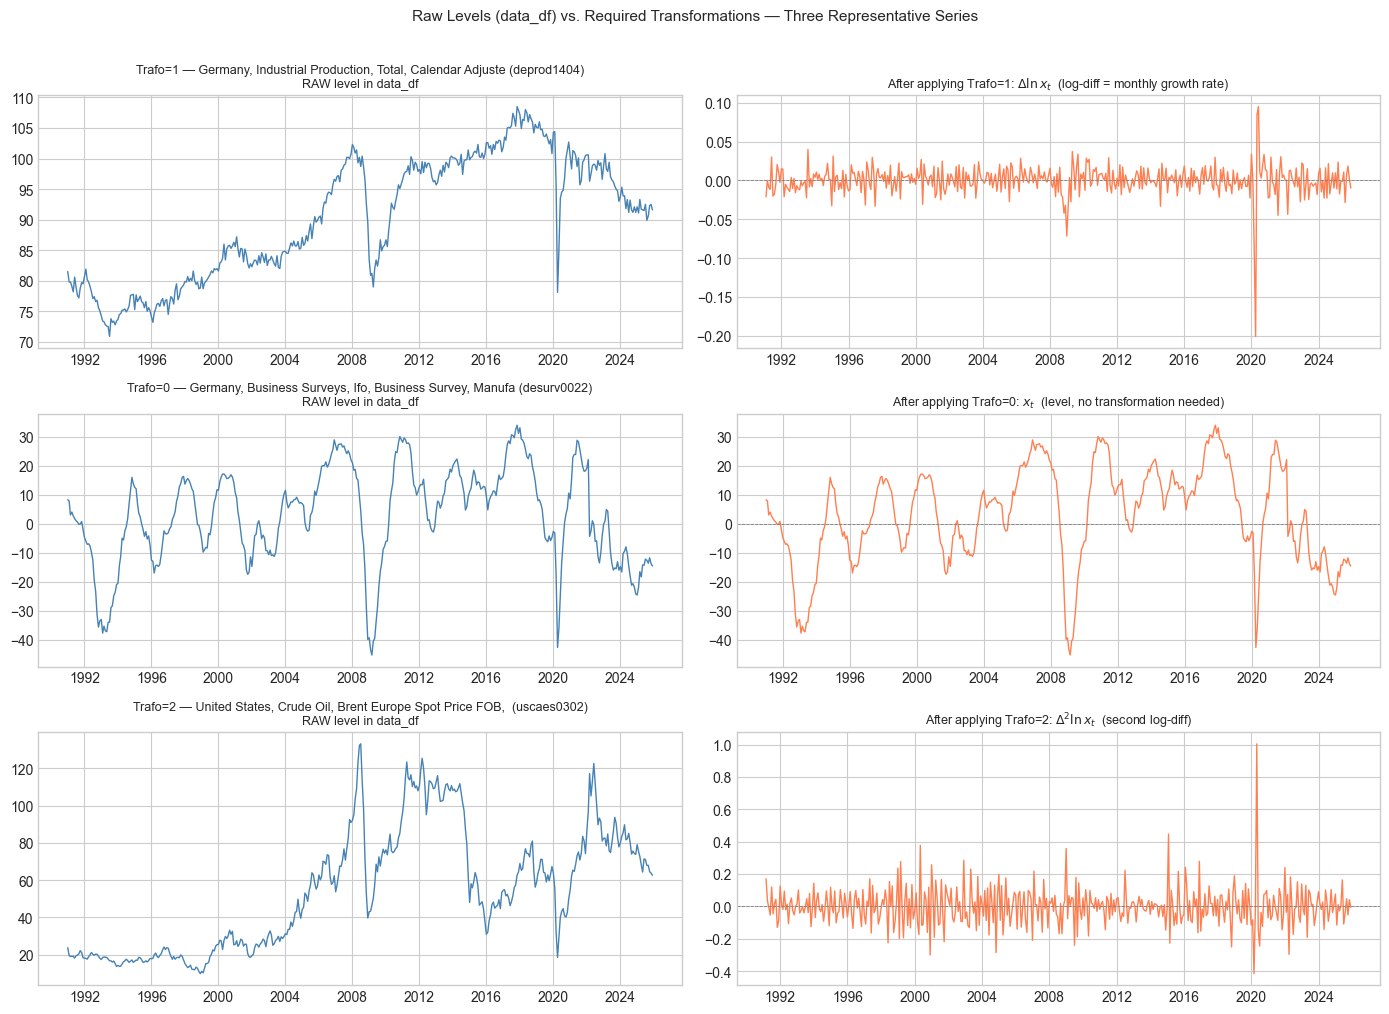


Conclusion: data_df contains RAW LEVELS. No transformation has been applied.
Transformations will be applied in Step 3, after the seasonality metadata step (Step 2).


In [4]:
# --- Step 1 — Representative series plots — levels vs. expected transformed form ---
# Visual check: one example per trafo code to visualise the raw vs. transformed difference.
# Preferred IDs are tried first; fall back to the longest-history series per trafo code
# (robust to deduplication / status-filtering in Step 0.5).

PREFERRED = {1: 'deprod1404', 0: 'desurv0022', 2: 'wocaes1117'}

def _pick_example(trafo_code: int) -> str:
    pref = PREFERRED.get(trafo_code)
    if pref and pref in data_df.columns:
        return pref
    candidates = data_dict[data_dict['trafo'] == trafo_code].index
    candidates = [c for c in candidates if c in data_df.columns]
    if not candidates:
        return None
    # Fallback: longest-history positive-valued series
    def _n_valid(c):
        s = data_df[c].dropna()
        return len(s) if (s > 0).all() else 0
    return max(candidates, key=_n_valid)

examples = {}
for t in [1, 0, 2]:
    sid = _pick_example(t)
    if sid is None:
        continue
    nm  = str(data_dict.loc[sid, 'name'])[:55]
    examples[f'Trafo={t} — {nm} ({sid})'] = (sid, t)

fig, axes = plt.subplots(len(examples), 2, figsize=(14, 10))

for row_idx, (title, (col_id, trafo)) in enumerate(examples.items()):
    raw = data_df[col_id].dropna()

    # Apply the indicated transformation for comparison
    if trafo == 1:
        transformed = np.log(raw).diff().dropna()
        t_label     = r'$\Delta\ln x_t$  (log-diff = monthly growth rate)'
    elif trafo == 2:
        transformed = np.log(raw).diff().diff().dropna()
        t_label     = r'$\Delta^2\ln x_t$  (second log-diff)'
    else:
        transformed = raw
        t_label     = r'$x_t$  (level, no transformation needed)'

    # Left: raw level
    axes[row_idx, 0].plot(raw.index, raw.values, linewidth=1.0, color='steelblue')
    axes[row_idx, 0].set_title(f'{title}\nRAW level in data_df', fontsize=9)
    axes[row_idx, 0].set_xlabel('')

    # Right: transformed version
    axes[row_idx, 1].plot(transformed.index, transformed.values,
                          linewidth=1.0, color='coral')
    axes[row_idx, 1].set_title(f'After applying Trafo={trafo}: {t_label}', fontsize=9)
    axes[row_idx, 1].axhline(0, color='gray', linewidth=0.6, linestyle='--')

plt.suptitle('Raw Levels (data_df) vs. Required Transformations — Three Representative Series',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'step1_raw_vs_transformed_examples.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nConclusion: data_df contains RAW LEVELS. No transformation has been applied.')
print('Transformations will be applied in Step 3, after the seasonality metadata step (Step 2).')

---
## Step 2 — Seasonality (metadata only)

ifoCAST series are **already seasonally adjusted** (Destatis / Bundesbank X-13-JDemetra+, ECB, OECD, etc.) or are **economically non-seasonal** (interest rates, survey balances, asset prices). We do **not** run X-13, SEATS, or STL in this notebook: `data_sa` is a copy of `data_df`.

For provenance, `data_dict['sa_status']` records `SA_source` for provider-adjusted real activity and price indices, and `no_sa_needed` for a small explicit list of rates, surveys, and similar series without a production-based seasonal cycle.


In [5]:
# --- Step 2 — Seasonality metadata (no adjustment applied) ---
data_sa = data_df.copy()

# Default: treat as source-side seasonally adjusted / calendar-adjusted macro flow
data_dict["sa_status"] = "SA_source"

# Series that are not production-seasonal by construction (rates, balances, some composites)
NO_SA_IDS = {
    "buba_mb_04314", "de10ygov_m", "buba_mb_04301",
    "deeqin0032",
    "deepunnewsindex", "euepunnewsindex",
    "ih:mb:com:cons_conf_world_weighted", "ih:mb:com:pmi_world_weighted",
    "ih:mb:com:ifoicde",
    "desurv0018", "desurv0017", "desurv0050", "desurv0073", "desurv0076",
    "delama0054", "delama0003", "delama0021",
    "deifo_c0000000_tkj_bdu", "deifo_cong0000_tkj_bdu", "deifo_c00000c0_tkj_bdu",
    "deifo_c0000cd0_tkj_bdu", "deifo_c0000cn0_tkj_bdu", "deifo_c00000a0_tkj_bdu",
    "deifo_c00000b0_tkj_bdu", "deifo_c2000000_tkj_bdu", "deifo_c2100000_tkj_bdu",
    "deifo_c2400000_tkj_bdu", "deifo_c2500000_tkj_bdu", "deifo_c2800000_tkj_bdu",
    "deifo_c2900000_tkj_bdu",
    "desurv9378", "desurv9362", "desurv9050", "desurv9034",
    "desurv8943", "desurv8946",
    "desurv00760", "desurv00763", "desurv00680", "desurv00683",
    "desurv00688", "desurv00691",
}
NO_SA_IDS = NO_SA_IDS & set(data_dict.index)
data_dict.loc[data_dict.index.isin(NO_SA_IDS), "sa_status"] = "no_sa_needed"

vc = data_dict["sa_status"].value_counts()
print("=== Seasonality metadata (no in-house adjustment) ===")
print(vc.to_string())
print()
print("data_sa equals data_df — no STL/X-13 applied.")


=== Seasonality metadata (no in-house adjustment) ===
sa_status
SA_source       546
no_sa_needed     39

data_sa equals data_df — no STL/X-13 applied.


---
## Step 3 — Apply Transformations

We apply the transformation codes from `data_dict['trafo']` to the panel `data_sa` (identical copy of `data_df`)
to produce the **stationary predictor panel** `data_transformed`.

| `trafo` | Formula | Economic interpretation |
|---------|---------|------------------------|
| 0 | $x_t$ (level, as-is) | Series already stationary — survey balances, rates, spreads |
| 1 | $\Delta \ln x_t = \ln x_t - \ln x_{t-1}$ | Monthly log-growth rate — production indices, trade, prices |
| 2 | $\Delta^2 \ln x_t$ | Change in growth rate — highly persistent growth rate series |

**Implementation notes:**
- Series with any non-positive values cannot be log-transformed; a simple first-difference $\Delta x_t$ is applied instead, and the deviation is flagged.
- The first 1–2 observations lost to differencing are `NaN` by construction and are retained as-is (not dropped).
- Convention follows Stock & Watson (2002) and McCracken & Ng (2016, FRED-MD).

In [6]:
# --- 3.1  Apply transformations ---

data_transformed = data_sa.copy()
non_positive_log  = []   # series where log cannot be applied

for col_id in data_sa.columns:
    trafo = int(data_dict.loc[col_id, 'trafo'])

    if trafo == 0:
        # Level — no transformation
        continue

    series = data_sa[col_id]
    has_nonpositive = (series.dropna() <= 0).any()

    if trafo == 1:
        if has_nonpositive:
            non_positive_log.append(col_id)
            data_transformed[col_id] = series.diff()           # fallback: Δx_t
        else:
            data_transformed[col_id] = np.log(series).diff()  # Δln(x_t)

    elif trafo == 2:
        if has_nonpositive:
            non_positive_log.append(col_id)
            data_transformed[col_id] = series.diff().diff()           # fallback: Δ²x_t
        else:
            data_transformed[col_id] = np.log(series).diff().diff()  # Δ²ln(x_t)

# Summary
print('=== Transformation Applied ===')
trafo_counts = data_dict['trafo'].value_counts().sort_index()
labels = {0: 'Level (as-is)', 1: 'Log-difference (Δln)', 2: 'Second log-diff (Δ²ln)'}
for t, n in trafo_counts.items():
    print(f'  Trafo={t}  {labels.get(int(t), "?"):<28s}: {n:>4d} series')
print()
if non_positive_log:
    print(f'WARNING — {len(non_positive_log)} series have non-positive values; simple difference used:')
    for sid in non_positive_log:
        m = data_dict.loc[sid]
        ser = data_sa[sid]
        neg_count = (ser < 0).sum()
        print(f'  Trafo={int(m["trafo"])} | {sid} | {str(m["name"])[:70]} | Negative values: {neg_count}')
   
else:
    print('All Trafo=1/2 series had strictly positive values. Log transformation applied throughout.')
print()
print(f'data_transformed shape: {data_transformed.shape}')
print(f'NaN count (first 2 rows are expected NaN from differencing): '
      f'{data_transformed.iloc[:2].isna().sum().sum()}')

=== Transformation Applied ===
  Trafo=0  Level (as-is)               :  398 series
  Trafo=1  Log-difference (Δln)        :  183 series
  Trafo=2  Second log-diff (Δ²ln)      :    4 series

WARNING — 2 series have non-positive values; simple difference used:
  Trafo=2 | de10ygov_m | Germany, Government Benchmarks, Bundesbank, 10 Year, Yield, End of Per | Negative values: 38
  Trafo=2 | buba_mb_04301 | Germany, Bundesbank, Money Market Rates, Euribor (R) Three-Month Funds | Negative values: 86

data_transformed shape: (420, 585)
NaN count (first 2 rows are expected NaN from differencing): 517


In [ ]:
# --- 3.2  Export transformed panel ---
transformed_path = _tp.PANEL_TRANSFORMED_CSV
data_transformed.to_csv(transformed_path)
print(f'Transformed panel saved : {transformed_path}')
print(f'  Shape : {data_transformed.shape}')
print(f'  Size  : {transformed_path.stat().st_size / 1e6:.1f} MB')

# Record which transformation was actually applied (incl. fallback cases)
data_dict['trafo_applied'] = data_dict['trafo'].copy()
for sid in non_positive_log:
    m_trafo = int(data_dict.loc[sid, 'trafo'])
    data_dict.at[sid, 'trafo_applied'] = -(m_trafo)  # negative = fallback to simple diff

print()
print('trafo_applied codes:')
print('   0  : level (no change)')
print('   1  : log-difference')
print('   2  : second log-difference')
print('  -1  : simple first-difference (fallback, non-positive values)')
print('  -2  : simple second-difference (fallback, non-positive values)')


---
## Step 4 — Stationarity Testing (ADF + KPSS)

We test each of the **retained transformed** series for stationarity using the **joint ADF + KPSS strategy**
standard in the nowcasting and macroeconometrics literature (Stock & Watson 2002; McCracken & Ng 2016).

### Tests

| Test | Null hypothesis | Reference |
|------|----------------|----------|
| **ADF** (Augmented Dickey-Fuller) | H₀: unit root present | Dickey & Fuller 1979; Elliott, Rothenberg & Stock 1996 |
| **KPSS** (Kwiatkowski-Phillips-Schmidt-Shin) | H₀: series is stationary | Kwiatkowski et al. 1992 |

### Joint decision rule

| ADF p-value | KPSS p-value | Verdict |
|-------------|-------------|--------|
| < 0.05 (reject unit root) | ≥ 0.05 (do not reject stationarity) | **Stationary** ✓ |
| ≥ 0.05 (unit root not rejected) | < 0.05 (reject stationarity) | **Non-stationary** ✗ |
| < 0.05 | < 0.05 | **Ambiguous — conflicting signals** (possible structural break or long memory) |
| ≥ 0.05 | ≥ 0.05 | **Ambiguous — both fail to reject** (low power) |

### Design choices

- **ADF:** lag selection via AIC, maximum 12 lags (one year, standard for monthly data).
- **KPSS:** `regression='c'` (demeaned, no deterministic trend), `nlags='auto'`.
- Significance level: **5%** for both tests.
- Series with fewer than 30 non-missing observations are flagged as `too_short` and skipped.

In [8]:
# --- 4.1  Unit-root test function ---

def test_unit_root(
    series: pd.Series,
    max_lags: int = 12,
    alpha: float  = 0.05,
) -> dict:
    """
    Joint ADF + KPSS stationarity test for a single time series.

    Parameters
    ----------
    series   : monthly time series (already transformed)
    max_lags : maximum lag length for ADF (AIC selection up to this bound)
    alpha    : significance level for both tests

    Returns
    -------
    dict with keys: n_obs, adf_stat, adf_p, adf_lags, kpss_stat, kpss_p, verdict

    References
    ----------
    Dickey & Fuller (1979); Elliott, Rothenberg & Stock (1996);
    Kwiatkowski, Phillips, Schmidt & Shin (1992).
    """
    clean = series.dropna()
    MIN_OBS = 30

    if len(clean) < MIN_OBS:
        return dict(n_obs=len(clean), adf_stat=np.nan, adf_p=np.nan, adf_lags=np.nan,
                    kpss_stat=np.nan, kpss_p=np.nan, verdict='too_short')

    # ADF
    adf_res  = adfuller(clean, maxlag=max_lags, autolag='AIC', regression='c')
    adf_stat = adf_res[0]
    adf_p    = adf_res[1]
    adf_lags = adf_res[2]

    # KPSS
    kpss_res  = kpss(clean, regression='c', nlags='auto')
    kpss_stat = kpss_res[0]
    kpss_p    = kpss_res[1]

    # Joint verdict
    adf_reject  = adf_p  < alpha
    kpss_reject = kpss_p < alpha

    if adf_reject and not kpss_reject:
        verdict = 'Stationary'
    elif not adf_reject and kpss_reject:
        verdict = 'Non-stationary'
    elif adf_reject and kpss_reject:
        verdict = 'Ambiguous_conflicting'
    else:
        verdict = 'Ambiguous_both_fail'

    return dict(
        n_obs     = len(clean),
        adf_stat  = round(adf_stat,  4),
        adf_p     = round(adf_p,     4),
        adf_lags  = int(adf_lags),
        kpss_stat = round(kpss_stat, 4),
        kpss_p    = round(kpss_p,    4),
        verdict   = verdict,
    )

print('test_unit_root() defined.')

test_unit_root() defined.


In [9]:
# --- 4.2  Run ADF + KPSS on all retained transformed series ---
# Modelling window: 1991-01 to 2025-12 (avoid future data beyond sample end)
MODEL_END = '2025-12'
panel     = data_transformed.loc[:MODEL_END]

print(f'Testing {panel.shape[1]} series over modelling window '
      f'({panel.index.min().strftime("%Y-%m")} → {MODEL_END}) ...')

results = []
for col_id in panel.columns:
    res = test_unit_root(panel[col_id])
    res['id'] = col_id
    results.append(res)

stat_df = pd.DataFrame(results).set_index('id')

# Merge with metadata
stat_df = stat_df.join(
    data_dict[['trafo', 'trafo_applied', 'sa_status', 'category', 'block', 'factor_data', 'name']]
)

print(f'Done.  Tested: {len(stat_df)} series')
print()
print('=== Verdict distribution ===')
print(stat_df['verdict'].value_counts().to_string())

Testing 585 series over modelling window (1991-01 → 2025-12) ...
Done.  Tested: 585 series

=== Verdict distribution ===
verdict
Stationary               367
Ambiguous_conflicting    133
Non-stationary            76
Ambiguous_both_fail        9


---
## Step 5 — Stationarity Summary, Problem Series, and Export

We summarise the test results, identify series that remain non-stationary or ambiguous after transformation,
and export the stationarity report and the enriched data dictionary.

**Decision rules for ambiguous series:**

| Verdict | Interpretation | Action |
|---------|---------------|--------|
| `Stationary` | ADF rejects unit root AND KPSS does not reject stationarity | Keep as-is |
| `Stationary_by_construction` | Survey balance (ifo / EC / GfK) with `trafo=0` — ADF/KPSS failed, but bounded support guarantees I(0) | **Keep at level; override test result.** See note below. |
| `Stationary_after_extra_diff` | Stationary only after Δ² (non-survey series) | Keep, flag `extra_diff=1` |
| `Ambiguous_conflicting` | ADF and KPSS give opposite signals | **Retain with current trafo.** With T ≈ 420 months, conflicting signals typically indicate a near-I(1) or highly persistent I(0) process — not a unit root. Domain-expert trafo codes take precedence over test tie-breaking (Stock & Watson 2016, McCracken & Ng 2016). |
| `Ambiguous_both_fail` | Both tests fail to reach significance (non-survey) | **Apply one extra difference** as a conservative hedge; re-test and flag. |
| `too_short` | Fewer than 30 non-missing obs | Exclude from stationarity assessment; handle at balanced-panel construction stage |

> **Survey balance exemption (ifo / EC / GfK — `trafo=0`, category=Surveys):**
> These series are constructed as the difference between the percentage share of positive and negative responses, bounding them to [−100, +100]. This bounded support is **structurally incompatible with a unit root** — a random walk cannot remain bounded over time.
>
> ADF and KPSS nonetheless fail on these series because near-unit-root persistence (median AC(1) ≈ 0.93 across the 80 affected series) is statistically indistinguishable from I(1) in T ≈ 420 observations (see Elliott, Rothenberg & Stock 1996 on ADF local power; Kwiatkowski et al. 1992 on KPSS size distortions under high persistence). Both tests are designed for unbounded processes and lose their theoretical guarantees when the DGP is I(0) but highly persistent.
>
> Applying an extra first-difference to these series would constitute **over-differencing**: it destroys the economic information content (the *level* of, e.g., the ifo business climate is the leading indicator for GDP, not its month-on-month change), inflates variance, and introduces a negative MA(1) unit root in the transformed series. The `Stationary_by_construction` verdict exempts all `trafo=0` survey balances from extra-differencing. 

In [10]:
# --- 5.1  Verdict breakdown by trafo code and category ---
print('=== Verdict by Trafo Code ===')
cross_trafo = pd.crosstab(stat_df['trafo'].astype(str), stat_df['verdict'])
print(cross_trafo.to_string())

print()
print('=== Verdict by Economic Category ===')
cross_cat = pd.crosstab(stat_df['category'], stat_df['verdict'])
print(cross_cat.to_string())

=== Verdict by Trafo Code ===
verdict  Ambiguous_both_fail  Ambiguous_conflicting  Non-stationary  Stationary
trafo                                                                          
0                          9                    132              76         181
1                          0                      1               0         182
2                          0                      0               0           4

=== Verdict by Economic Category ===
verdict       Ambiguous_both_fail  Ambiguous_conflicting  Non-stationary  Stationary
category                                                                            
Commodities                     0                      0               0           2
Construction                    0                      0               0           5
Financial                       0                      0               0           4
Global                          0                      0               1           5
Misc                  

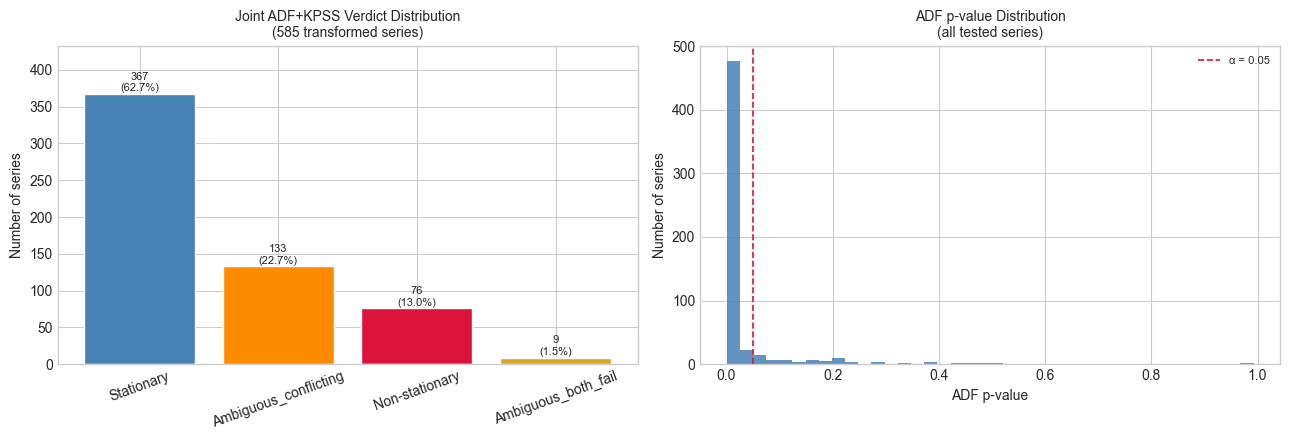

In [11]:
# --- 5.2  Stationarity verdict distribution plot ---
verdict_counts = stat_df['verdict'].value_counts()
n_total        = len(stat_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: overall verdict distribution
colors = {
    'Stationary'            : 'steelblue',
    'Non-stationary'        : 'crimson',
    'Ambiguous_conflicting' : 'darkorange',
    'Ambiguous_both_fail'   : 'goldenrod',
    'too_short'             : 'lightgray',
}
bar_colors = [colors.get(v, 'gray') for v in verdict_counts.index]
bars = axes[0].bar(verdict_counts.index, verdict_counts.values, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, verdict_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{val}\n({val/n_total*100:.1f}%)', ha='center', va='bottom', fontsize=8)
axes[0].set_title(f'Joint ADF+KPSS Verdict Distribution\n({n_total} transformed series)', fontsize=10)
axes[0].set_ylabel('Number of series')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, verdict_counts.max() * 1.18)

# Right: ADF p-value distribution
axes[1].hist(stat_df['adf_p'].dropna(), bins=40, color='steelblue', edgecolor='none', alpha=0.85)
axes[1].axvline(0.05, color='crimson', linestyle='--', linewidth=1.2, label='α = 0.05')
axes[1].set_title('ADF p-value Distribution\n(all tested series)', fontsize=10)
axes[1].set_xlabel('ADF p-value')
axes[1].set_ylabel('Number of series')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'step4_stationarity_verdicts.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# --- 5.3  Identify and inspect problem series ---
# Ambiguous_conflicting → retain (see decision rule in Step 5 markdown)
# Ambiguous_both_fail   → apply extra diff (conservative; both tests uninformative)
# Non-stationary        → apply extra diff
#
# EXEMPTION: survey balance series (trafo=0 AND category=Surveys)
# These are bounded to [-100, +100] by construction and cannot have a unit root.
# ADF/KPSS failures are a finite-sample artefact of high persistence (median AC1≈0.93).
# They are kept at level and flagged 'Stationary_by_construction'.
# See Step 5 markdown for the full methodological justification.
display_cols = ['trafo', 'category', 'adf_p', 'kpss_p', 'verdict', 'name']

# Mark survey balances before differencing loop
survey_balance_mask = (
    (stat_df['trafo'] == 0) &
    stat_df['category'].str.lower().str.contains('survey', na=False)
)
stat_df.loc[
    survey_balance_mask & stat_df['verdict'].isin(['Non-stationary', 'Ambiguous_both_fail']),
    'verdict'
] = 'Stationary_by_construction'

for label, verdicts in [
    ('Ambiguous_conflicting (retained, trafo trusted)',            ['Ambiguous_conflicting']),
    ('Stationary_by_construction (survey balance, level kept)',   ['Stationary_by_construction']),
    ('Ambiguous_both_fail + Non-stationary (extra diff applied)', ['Ambiguous_both_fail', 'Non-stationary']),
]:
    sub = stat_df[stat_df['verdict'].isin(verdicts)]
    print(f'\n{label} : {len(sub)}')
    if not sub.empty:
        print(sub[display_cols].to_string())

# Apply one extra difference ONLY to non-survey Non-stationary and Ambiguous_both_fail
extra_diff_verdicts = ['Non-stationary', 'Ambiguous_both_fail']
extra_diff_ids = stat_df[stat_df['verdict'].isin(extra_diff_verdicts)].index.tolist()
if extra_diff_ids:
    print(f'\nApplying extra first-difference to {len(extra_diff_ids)} series ...')
    for sid in extra_diff_ids:
        original_verdict = stat_df.at[sid, 'verdict']
        data_transformed[sid] = data_transformed[sid].diff()
        stat_df.at[sid, 'verdict'] = original_verdict + '_extra_diff'
    print('Done.')
else:
    print('\nNo extra differencing required.')


Ambiguous_conflicting (retained, trafo trusted) : 133
                        trafo  category   adf_p  kpss_p                verdict                                                                                                                                                                                                                                                                                name
id                                                                                                                                                                                                                                                                                                                                                                
detrad1360                  1  Turnover  0.0000  0.0464  Ambiguous_conflicting                                                                                                                      Germany, Domestic Trade, Retail Trade, 

In [13]:
# --- 5.4  Re-test non-stationary series after extra difference ---
ns_ids = stat_df[stat_df['verdict'] == 'Non-stationary_extra_diff'].index.tolist()

if ns_ids:
    panel_retest = data_transformed.loc[:MODEL_END]
    print(f'Re-testing {len(ns_ids)} series after extra difference:')
    for sid in ns_ids:
        res = test_unit_root(panel_retest[sid])
        stat_df.at[sid, 'verdict'] = res['verdict'] + '_after_extra_diff'
        print(f'  {sid}: ADF p={res["adf_p"]:.4f}, KPSS p={res["kpss_p"]:.4f} → {res["verdict"]}')
else:
    print('No series required re-testing.')

Re-testing 3 series after extra difference:
  deepunnewsindex: ADF p=0.0000, KPSS p=0.1000 → Stationary
  euepunnewsindex: ADF p=0.0000, KPSS p=0.1000 → Stationary
  wotrad0018: ADF p=0.0000, KPSS p=0.1000 → Stationary


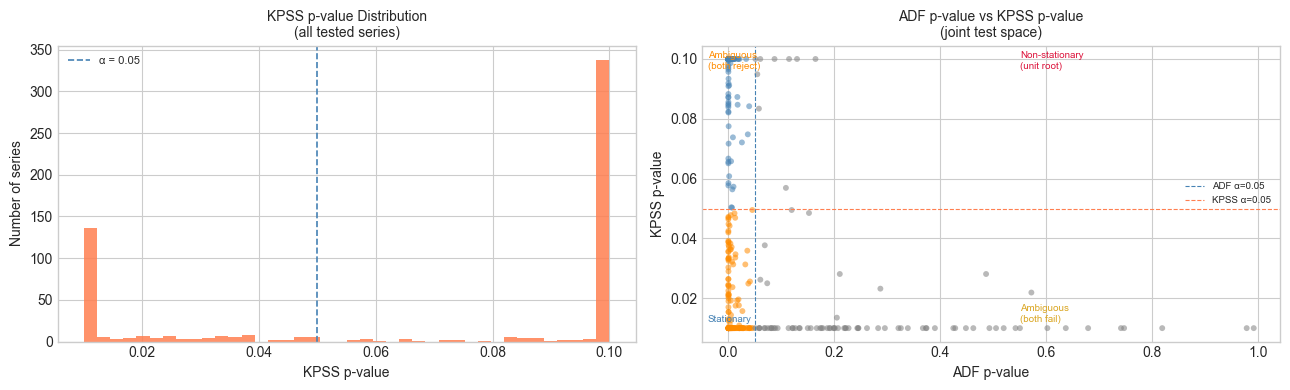

In [14]:
# --- 5.5  KPSS p-value distribution plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: KPSS p-value distribution
axes[0].hist(stat_df['kpss_p'].dropna(), bins=40, color='coral', edgecolor='none', alpha=0.85)
axes[0].axvline(0.05, color='steelblue', linestyle='--', linewidth=1.2, label='α = 0.05')
axes[0].set_title('KPSS p-value Distribution\n(all tested series)', fontsize=10)
axes[0].set_xlabel('KPSS p-value')
axes[0].set_ylabel('Number of series')
axes[0].legend(fontsize=8)

# Right: Scatter ADF p vs KPSS p — joint test space
tested = stat_df.dropna(subset=['adf_p', 'kpss_p'])
v_colors = tested['verdict'].map({
    'Stationary'            : 'steelblue',
    'Non-stationary'        : 'crimson',
    'Ambiguous_conflicting' : 'darkorange',
    'Ambiguous_both_fail'   : 'goldenrod',
}).fillna('gray')
axes[1].scatter(tested['adf_p'], tested['kpss_p'],
                c=v_colors, alpha=0.55, s=18, edgecolors='none')
axes[1].axvline(0.05, color='steelblue', linestyle='--', linewidth=0.8, label='ADF α=0.05')
axes[1].axhline(0.05, color='coral',     linestyle='--', linewidth=0.8, label='KPSS α=0.05')
axes[1].set_title('ADF p-value vs KPSS p-value\n(joint test space)', fontsize=10)
axes[1].set_xlabel('ADF p-value')
axes[1].set_ylabel('KPSS p-value')

# Annotate quadrants
axes[1].text(0.01, 0.98, 'Ambiguous\n(both reject)', transform=axes[1].transAxes,
             fontsize=7, va='top', color='darkorange')
axes[1].text(0.55, 0.98, 'Non-stationary\n(unit root)', transform=axes[1].transAxes,
             fontsize=7, va='top', color='crimson')
axes[1].text(0.01, 0.06, 'Stationary', transform=axes[1].transAxes,
             fontsize=7, va='bottom', color='steelblue')
axes[1].text(0.55, 0.06, 'Ambiguous\n(both fail)', transform=axes[1].transAxes,
             fontsize=7, va='bottom', color='goldenrod')
axes[1].legend(fontsize=7, loc='center right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'step4_adf_kpss_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- 5.6  Export outputs ---

# 1. Stationarity report
stat_path = _tp.STATIONARITY_REPORT_CSV
export_cols = ['trafo', 'trafo_applied', 'category', 'block', 'factor_data',
               'n_obs', 'adf_stat', 'adf_p', 'adf_lags', 'kpss_stat', 'kpss_p', 'verdict', 'name']
stat_df[export_cols].to_csv(stat_path)
print(f'Stationarity report saved : {stat_path}')
print(f'  Shape : {stat_df.shape}')

# 2. Enriched data dictionary (includes pub_lag from Step 0.6)
dict_path = _tp.DATA_DICT_ENRICHED_CSV
# Ensure pub_lag column is present (added in Step 0.6)
if 'pub_lag' not in data_dict.columns:
    data_dict['pub_lag'] = data_dict.index.map(
        pd.read_csv(_tp.PUB_LAG_CSV).set_index('id')['pub_lag']
    ).fillna(0).astype(int)
data_dict.to_csv(dict_path)
print(f'Enriched data dict saved  : {dict_path}')
print(f'  Shape : {data_dict.shape}')
print(f'  pub_lag distribution: {data_dict["pub_lag"].value_counts().to_dict()}')

# 3. Final transformed panel (includes extra-differenced series + new series from Step 0.6)
transformed_path = _tp.PANEL_TRANSFORMED_CSV
data_transformed.to_csv(transformed_path)
print(f'Transformed panel saved   : {transformed_path}  ({data_transformed.shape})')


In [ ]:
# --- Summary Report ---
SEP = '=' * 64
print(SEP)
print('  02 — Data Preparation Summary')
print(SEP)

print('\n--- STEP 0.5  DEDUPLICATION & STATUS FILTER ---')
print(f'  Duplicates dropped      : {len(ids_to_drop):>4d}')
print(f'  Discontinued dropped    : {len(discontinued_ids):>4d}  (> {DISCONTINUED_MONTHS} months without update)')
print(f'  Sparse dropped          : {len(sparse_ids):>4d}  (> {MAX_MISSING_RATE:.0%} missing rate)')
print(f'  Retained series         : {data_df.shape[1]:>4d}')
print('  Status distribution (retained):')
for s, n in data_dict['status'].value_counts().items():
    print(f'    {s:<14s} : {n:>4d}')

print(f'  SA metadata : SA_source vs no_sa_needed (no STL/X-13 applied)')

print('\n--- TRANSFORMATIONS APPLIED ---')
labels = {0: 'Level (as-is)', 1: 'Log-diff (growth rate)', 2: 'Second log-diff (Δ²ln)',
          -1: 'Simple diff (fallback Trafo=1)', -2: 'Second simple diff (fallback Trafo=2)'}
for t, n in data_dict['trafo_applied'].value_counts().sort_index().items():
    print(f'  Trafo={int(t):+d}  {labels.get(int(t), "?"):<36s}: {n:>4d} series')

print('\n--- STATIONARITY TEST RESULTS (after all applied transformations incl. extra differencing) ---')
for verdict, count in stat_df['verdict'].value_counts().items():
    pct = count / len(stat_df) * 100
    # Explicitly explain how "Ambiguous_conflicting" is handled (user query)
    if verdict == 'Ambiguous_conflicting':
        explanation = (
            "    → ADF and KPSS gave conflicting results, but\n"
            "      transformation follows expert/official 'trafo' code (as in Stock & Watson, 2016; McCracken & Ng, 2016):\n"
            "      Most likely a highly persistent stationary series (not a true unit root),\n"
            "      so we TRUST the trafo and treat as stationary for modelling.\n"
            "      No further differencing is applied."
        )
        print(f'  {verdict:<35s}: {count:>4d}  ({pct:.1f}%)')
        print(explanation)
    else:
        print(f'  {verdict:<35s}: {count:>4d}  ({pct:.1f}%)')
print('\nNote: These results reflect the post-transformation state of all series — i.e., after initial trafo, and after any necessary second differencing for nonstationary series.\n'
      "      In particular, for 'Ambiguous_conflicting', conservative logics and domain expertise are used to avoid over-differencing.")

print('\n--- OUTPUT FILES ---')
print(f'  {_tp.PANEL_TRANSFORMED_CSV}     ← stationary predictor panel')
print(f'  {_tp.STATIONARITY_REPORT_CSV}  ← per-series ADF+KPSS results')
print(f'  {_tp.DATA_DICT_ENRICHED_CSV}   ← metadata + sa_status + trafo_applied')
print(f'  {FIG_DIR}/                             ← all figures')
print(f'\n{SEP}')
